📌 Feature Engineering - Introduction
🔹 What is Feature Engineering?
Feature Engineering is the process of transforming raw data into useful features that help machine learning models perform better.

👉 In simple terms: We convert data into a form that machines can understand easily.

🔹 Why is Feature Engineering Important?
Improves model accuracy
Helps in better data understanding
Removes noise and unnecessary information
Makes patterns more visible
🔹 Types of Features
1. Numerical Features
Continuous values
Example: Age, Salary, Temperature
2. Categorical Features
Labels or categories
Example: Gender, City, Color
3. Text Features
Words or sentences
Example: Reviews, Comments
4. Date-Time Features
Time-based data
Example: Date, Timestamp
🎯 Goal of Feature Engineering
Convert raw data ➡️ meaningful inputs for ML models

In [1]:
import pandas as pd

# Sample dataset
data = {
    "Name": ["Alice", "Bob", "Charlie"],
    "Age": [25, 30, 35],
    "Gender": ["Female", "Male", "Male"],
    "Salary": [50000, 60000, 70000],
    "Joining_Date": ["2022-01-01", "2021-06-15", "2020-03-20"]
}

df = pd.DataFrame(data)

# Display dataset
df

,Name,Age,Gender,Salary,Joining_Date
0,Alice,25,Female,50000,2022-01-01
1,Bob,30,Male,60000,2021-06-15
2,Charlie,35,Male,70000,2020-03-20


In [2]:
# Check data types
df.dtypes

,0
Name,object
Age,int64
Gender,object
Salary,int64
Joining_Date,object


Age & Salary → Numerical Features
Gender → Categorical Feature
Name → Text Feature
Joining_Date → Date-Time Feature

📌 Handling Numerical Data
🔹 What is Numerical Data?
Numerical data consists of numbers and can be measured.

👉 Examples:

Age
Salary
Temperature
🔹 Why do we need to process numerical data?
Different features may have different scales
Large values can dominate smaller ones
Models perform better when data is properly scaled
🔹 1. Feature Scaling
📌 Standardization
Converts data to mean = 0 and standard deviation = 1
📌 Normalization (Min-Max Scaling)
Scales values between 0 and 1
🔹 2. Log Transformation
Used to reduce skewness in data
Helps in handling large values
🔹 3. Binning (Discretization)
Converts continuous values into categories
Example: Age → Young, Adult, Old

In [3]:
import pandas as pd
import numpy as np

# Sample numerical data
data = {
    "Age": [18, 29, 30, 40, 60],
    "Salary": [20000, 30000, 50000, 80000, 150000]
}

df = pd.DataFrame(data)
df

,Age,Salary
0,18,20000
1,29,30000
2,30,50000
3,40,80000
4,60,150000


Feature Scaling – Standardization

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[["Age", "Salary"]] = scaler.fit_transform(df[["Age", "Salary"]])

df_scaled

,Age,Salary
0,-1.230858,-0.984309
1,-0.452729,-0.770329
2,-0.381990,-0.342368
3,0.325399,0.299572
4,1.740179,1.797434


Feature Scaling – Normalization (Min-Max)

In [5]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_normalized = df.copy()
df_normalized[["Age", "Salary"]] = scaler.fit_transform(df[["Age", "Salary"]])

df_scaled

,Age,Salary
0,-1.230858,-0.984309
1,-0.452729,-0.770329
2,-0.381990,-0.342368
3,0.325399,0.299572
4,1.740179,1.797434


Log Transformation

In [6]:
#Apply log transformation
df_log = df.copy()
df_log["Salary_log"] = np.log(df_log["Salary"])

df_log

,Age,Salary,Salary_log
0,18,20000,9.903488
1,29,30000,10.308953
2,30,50000,10.819778
3,40,80000,11.289782
4,60,150000,11.918391


Binning (Discretization)

In [7]:
#Create bins for Age
bins = [0, 20, 40, 100]
labels = ["Young", "Adult", "senior"]

df["Age_Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

df

,Age,Salary,Age_Group
0,18,20000,Young
1,29,30000,Adult
2,30,50000,Adult
3,40,80000,Adult
4,60,150000,senior


Standardization → Used in algorithms like Logistic Regression, SVM
Normalization → Used in Neural Networks
Log Transform → Reduces skewed data
Binning → Converts numbers into categories

Handling Categorical Data

📌 Handling Categorical Data
🔹 What is Categorical Data?
Categorical data represents labels or categories.

👉 Examples:

Gender (Male/Female)
City (Mumbai, Delhi, Pune)
Color (Red, Blue, Green)
🔹 Why convert categorical data?
Machine Learning models work with numbers, not text.

👉 So we convert categories ➝ numerical form

🔹 Encoding Techniques
1. Label Encoding
Converts categories into numbers
Example: Male → 0, Female → 1
2. One-Hot Encoding
Creates separate columns for each category
Uses 0 and 1
3. Ordinal Encoding
Used when categories have order
Example: Low < Medium < High
4. Frequency Encoding
Replace category with its frequency
5. Target Encoding (Basic Idea)
Replace category with mean of target variable

In [12]:
import pandas as pd

data = {
    "Name": ["A", "B", "C", "D", "E","F"],
    "Gender": ["Male", "Female", "Female", "Male", "B","Female"],
    "City": ["Mumbai", "Delhi", "Mumbai", "Pune", "Delhi","Delhi"],
    "Performance": ["Low", "Medium", "High", "Medium", "Low","High"]
}

df = pd.DataFrame(data)
df

,Name,Gender,City,Performance
0,A,Male,Mumbai,Low
1,B,Female,Delhi,Medium
2,C,Female,Mumbai,High
3,D,Male,Pune,Medium
4,E,B,Delhi,Low
5,F,Female,Delhi,High


Label Encoding

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])
df["City_Label"] = le.fit_transform(df["City"])
df

,Name,Gender,City,Performance,Gender_Label,City_Label
0,A,Male,Mumbai,Low,2,1
1,B,Female,Delhi,Medium,1,0
2,C,Female,Mumbai,High,1,1
3,D,Male,Pune,Medium,2,2
4,E,B,Delhi,Low,0,0
5,F,Female,Delhi,High,1,0


Ordinal Encoding

In [14]:
# Define order
order = {"Low": 3, "Medium": 2, "High": 1}

df["Performance_Ordinal"] = df["Performance"].map(order)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal
0,A,Male,Mumbai,Low,2,1,3
1,B,Female,Delhi,Medium,1,0,2
2,C,Female,Mumbai,High,1,1,1
3,D,Male,Pune,Medium,2,2,2
4,E,B,Delhi,Low,0,0,3
5,F,Female,Delhi,High,1,0,1


Frequency Encoding

In [15]:
freq = df["City"].value_counts()

df["City_Freq"] = df["City"].map(freq)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq
0,A,Male,Mumbai,Low,2,1,3,2
1,B,Female,Delhi,Medium,1,0,2,3
2,C,Female,Mumbai,High,1,1,1,2
3,D,Male,Pune,Medium,2,2,2,1
4,E,B,Delhi,Low,0,0,3,3
5,F,Female,Delhi,High,1,0,1,3


Target Encoding (Basic Idea)

In [16]:
# Create a dummy target variable
df["Target"] = [0, 1, 1, 0, 1,2]

# Calculate mean target per category
target_mean = df.groupby("City")["Target"].mean()

df["City_Target_Encoded"] = df["City"].map(target_mean)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq,Target,City_Target_Encoded
0,A,Male,Mumbai,Low,2,1,3,2,0,0.500000
1,B,Female,Delhi,Medium,1,0,2,3,1,1.333333
2,C,Female,Mumbai,High,1,1,1,2,1,0.500000
3,D,Male,Pune,Medium,2,2,2,1,0,0.000000
4,E,B,Delhi,Low,0,0,3,3,1,1.333333
5,F,Female,Delhi,High,1,0,1,3,2,1.333333


Label Encoding → Simple, but not good for unordered data
One-Hot Encoding → Most commonly used
Ordinal Encoding → Use when order exists
Frequency Encoding → Useful for high-cardinality data
Target Encoding → Advanced, used in competitions

📌 Handling Date & Time Features
🔹 What is Date-Time Data?
Date-Time data represents time-related information.

👉 Examples:

Joining Date
Timestamp
Order Date
🔹 Why use Date-Time Features?
Helps in finding patterns over time
Useful in trends, seasonality, and time-based predictions
🔹 Common Feature Extraction
📌 Extract from Date:
Year
Month
Day
Weekday
📌 Time-Based Features:
Hour
Minute
Second
📌 Cyclical Encoding (Basic Idea)
Some features repeat (like months, days)
Example: December (12) is close to January (1)
Use Sin & Cos transformation to preserve this pattern

In [17]:
import pandas as pd

data = {
    "Name": ["A", "B", "C"],
    "Joining_Date": ["2022-01-15", "2021-06-20", "2020-12-05"]
}

df = pd.DataFrame(data)

df.info()
# Convert to datetime
df["Joining_Date"] = pd.to_datetime(df["Joining_Date"])

df

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          3 non-null      object
 1   Joining_Date  3 non-null      object
dtypes: object(2)
memory usage: 180.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          3 non-null      object        
 1   Joining_Date  3 non-null      datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 180.0+ bytes


Extract Date Features

In [18]:
df["Year"] = df["Joining_Date"].dt.year
df["Month"] = df["Joining_Date"].dt.month
df["Day"] = df["Joining_Date"].dt.day
df["dayname"] = df["Joining_Date"].dt.day_name()

df

,Name,Joining_Date,Year,Month,Day,dayname
0,A,2022-01-15,2022,1,15,Saturday
1,B,2021-06-20,2021,6,20,Sunday
2,C,2020-12-05,2020,12,5,Saturday


Extract Time Features

In [19]:
# Create sample datetime with time
df["Full_DateTime"] = pd.to_datetime([
    "2022-01-15 10:30:00",
    "2021-06-20 14:45:00",
    "2020-12-05 08:15:00"
])

df["Hour"] = df["Full_DateTime"].dt.hour
df["Minute"] = df["Full_DateTime"].dt.minute

df

,Name,Joining_Date,Year,Month,Day,dayname,Full_DateTime,Hour,Minute
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15


In [20]:
import numpy as np
#Cyclical encoding converts months into circular values so the model understands that December and January are adjacent months.
# Apply on Month
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

df

,Name,Joining_Date,Year,Month,Day,dayname,Full_DateTime,Hour,Minute,Month_sin,Month_cos
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30,5.000000e-01,0.866025
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45,1.224647e-16,-1.000000
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15,-2.449294e-16,1.000000


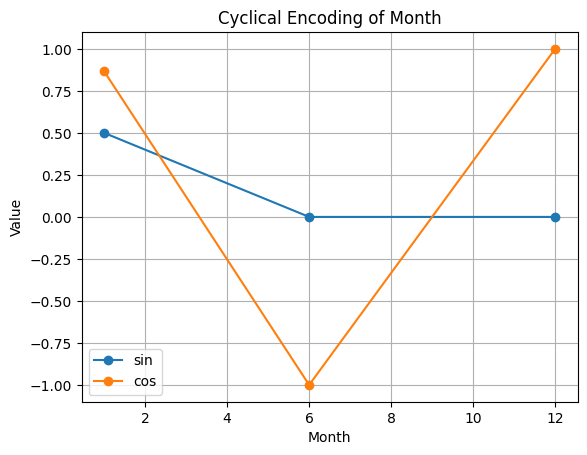

In [21]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(df["Month"], df["Month_sin"], marker='o', label="sin")
plt.plot(df["Month"], df["Month_cos"], marker='o', label="cos")

plt.xlabel("Month")
plt.ylabel("Value")
plt.title("Cyclical Encoding of Month")
plt.legend()
plt.grid()

plt.show()

Extracting features helps model understand time patterns
Weekday helps identify behavior (e.g., weekends vs weekdays)
Cyclical encoding preserves circular nature of time

📌 Feature Creation
🔹 What is Feature Creation?
Feature Creation means creating new features from existing data to improve model performance.

👉 In simple terms: We make new useful columns from old ones.

🔹 Why is it important?
Helps model learn better patterns
Adds more meaningful information
Improves accuracy
🔹 Types of Feature Creation
📌 1. Mathematical Transformations
Addition, subtraction, multiplication
Example: Total = Price × Quantity
📌 2. Combining Features
Merge two columns into one
Example: First Name + Last Name
📌 3. Extracting Information
From text or existing columns
Example: Email → Domain
📌 4. Domain-Based Features (Basic Idea)
Based on real-world knowledge
Example: BMI = Weight / Height²

In [22]:
import pandas as pd

data = {
    "Name": ["A", "B", "C"],
    "Price": [100, 200, 150],
    "Quantity": [2, 3, 5],
    "First_Name": ["John", "Jane", "Sam"],
    "Last_Name": ["Doe", "Smith", "Brown"],
    "Email": ["john@gmail.com", "jane@yahoo.com", "sam@outlook.com"]
}

df = pd.DataFrame(data)
df

,Name,Price,Quantity,First_Name,Last_Name,Email
0,A,100,2,John,Doe,john@gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com


Mathematical Feature Creation

In [23]:
# Create Total Price
df["Total_Price"] = df["Price"] * df["Quantity"]

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price
0,A,100,2,John,Doe,john@gmail.com,200
1,B,200,3,Jane,Smith,jane@yahoo.com,600
2,C,150,5,Sam,Brown,sam@outlook.com,750


Combining Features

In [24]:
# Full Name
df["Full_Name"] = df["First_Name"] + " " + df["Last_Name"]

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name
0,A,100,2,John,Doe,john@gmail.com,200,John Doe
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown


Extracting Information

In [25]:
# Extract email domain
df["Email_Domain"] = df["Email"].apply(lambda x: x.split("@")[1])

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com


Domain-Based Feature (Example: IBM)

In [26]:
# Add sample data
df["Weight"] = [60, 70, 80]   # kg
df["Height"] = [1.6, 1.7, 1.8]  # meters

# BMI Formula
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain,Weight,Height,BMI
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com,60,1.6,23.437500
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com,70,1.7,24.221453
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com,80,1.8,24.691358


Feature creation adds new useful information
Total_Price helps understand spending
Full_Name combines identity info
Email domain can show user type
BMI is a real-world meaningful feature

📌 Handling Missing Values
🔹 What are Missing Values?
Missing values are empty or null data in a dataset.

👉 Examples:

NaN
None
Blank cells
🔹 Why handle missing values?
ML models cannot handle missing data
Can reduce accuracy
May cause errors in computation
🔹 Common Techniques
📌 1. Mean Imputation
Replace missing values with average
📌 2. Median Imputation
Replace with middle value
Useful for skewed data
📌 3. Mode Imputation
Replace with most frequent value
📌 4. Forward Fill
Fill using previous value
📌 5. Backward Fill
Fill using next value
📌 6. Missing Indicator
Create a column to mark missing values

